# Chapter 2 - End-to-End ML Project

In this chapter, we will build one complete Machine Learning project from start to finish.
The problem is small on purpose: predict whether a student is likely to get placed
using two input features, `cgpa` and `iq`.

The goal is not only to train a model.

The goal is to understand how the major
project steps connect with each other: data ingestion, preprocessing, exploratory
analysis, feature engineering, model building, model evaluation, and final
interpretation.

 ## Google Colab Notebook

  Google Colab is an online notebook where we can write and run Python code in small cells. It is useful
  for Machine Learning because we can load data, clean it, create plots, train a model, and see the output
  step by step in the same place.

  In this project, we will use this current notebook like a practical workspace. Each section will perform one part
  of the ML project, starting from loading the placement dataset and ending with model evaluation.

## Step 1 - Project Overview

The Training and Placement Cell of a university wants to identify which students
are likely to secure job placements after graduation.

This is a supervised learning problem because the historical data already contains
the final answer for each student: placed (`Yes`) or not placed (`No`). We will use
that labelled data to train a Logistic Regression model.

The dataset contains three columns:

- `cgpa`: cumulative grade point average of the student
- `iq`: intelligence quotient score of the student
- `placement`: whether the student was placed

## Step 2 - Data Ingestion

Data ingestion means loading the raw data into Python so that we can inspect and
process it. The chapter uses a CSV file named `pl_data.csv`. We load the local file
first so that the notebook runs inside this repository without depending on the
internet.

In [30]:
# import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# github link where our csv data is stored
url = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch02/pl_data.csv"

# read the data from our given github link and load it locally
raw_df = pd.read_csv(url)

print("First 5 rows of the raw dataset:")
print(raw_df.head())

print("\nNumber of rows and columns:")
print(raw_df.shape)

print("\nSummary of the raw DataFrame:")
raw_df.info()

print("\nNumber of duplicate rows:")
print(raw_df.duplicated().sum())

First 5 rows of the raw dataset:
  cgpa     iq placement
0  6,8  123.0       Yes
1  5,9  106.0        No
2  5,3  121.0        No
3  7,4  132.0       Yes
4  5,8  142.0        No

Number of rows and columns:
(100, 3)

Summary of the raw DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     str    
 1   iq         100 non-null    float64
 2   placement  100 non-null    str    
dtypes: float64(1), str(2)
memory usage: 2.5 KB

Number of duplicate rows:
0


The first inspection tells us three important things.

- The dataset has 100 rows and 3 columns.
- `cgpa` has been read as text because values use a comma as the decimal separator.
- `placement` is also text, so it must be converted before modelling.

## Step 3 - Data Preprocessing

Machine Learning models expect clean numeric input. In this step we convert the
columns into useful formats:

- replace the comma in `cgpa` values with a decimal point
- convert `cgpa` from text to floating point numbers
- convert `placement` from `Yes` / `No` into `1` / `0`

In [39]:
df = raw_df.copy()

# CGPA values such as "6,8" are written with a comma decimal separator.
# Replacing the comma with a dot lets Python parse them as real numbers.
df["cgpa"] = df["cgpa"].str.replace(",", ".", regex=False).astype(float)

# Logistic Regression needs a numeric target, 
# so Yes becomes 1 and No becomes 0.
df["placement"] = df["placement"].map({"Yes": 1, "No": 0})

print("Cleaned preview:")
print(df.head())

print("\nColumn data types after conversion:")
print(df.dtypes)

Cleaned preview:
   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0

Column data types after conversion:
cgpa         float64
iq           float64
placement      int64
dtype: object


Before we proceed, we check basic descriptive statistics. This helps us notice the
range of values, missing values, and suspicious extreme values.

In [32]:
print("Descriptive statistics:")
print(df.describe())

Descriptive statistics:
            cgpa          iq   placement
count  95.000000  100.000000  100.000000
mean    5.988421  123.580000    0.500000
std     1.157112   39.944198    0.502519
min     3.300000   37.000000    0.000000
25%     5.000000  101.500000    0.000000
50%     6.000000  127.500000    0.500000
75%     6.900000  149.000000    1.000000
max     8.500000  233.000000    1.000000


In [33]:
print("\nMissing values in each column:")
print(df.isna().sum())


Missing values in each column:
cgpa         5
iq           0
placement    0
dtype: int64


The above output shows that "cgpa" column has 5 missing values while other columns have zero missing values. This tells us that we will need to do feature engineering for this "cgpa" column so that we can fix its missing value issue.

## Step 4 - Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand each variable before building
the model. We start with univariate analysis, where we study one column at a time.

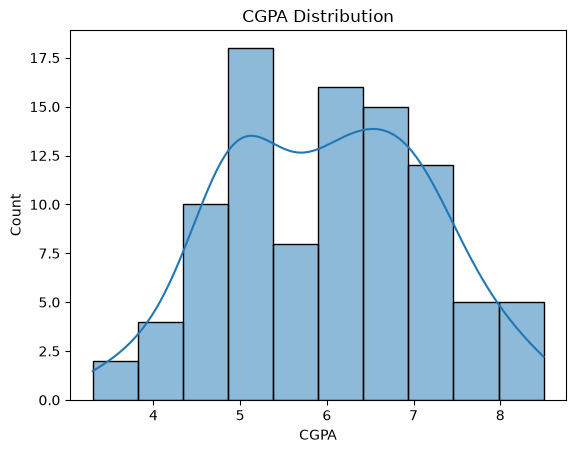

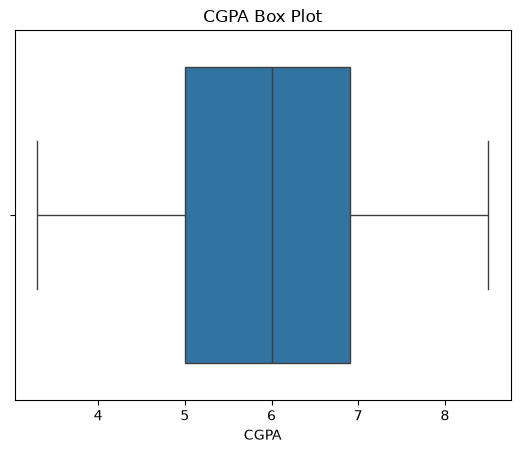

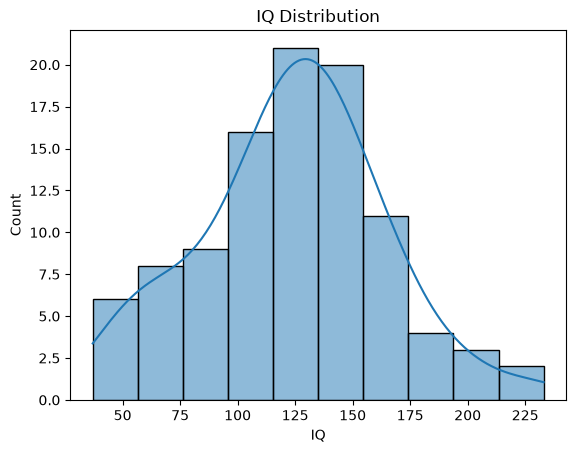

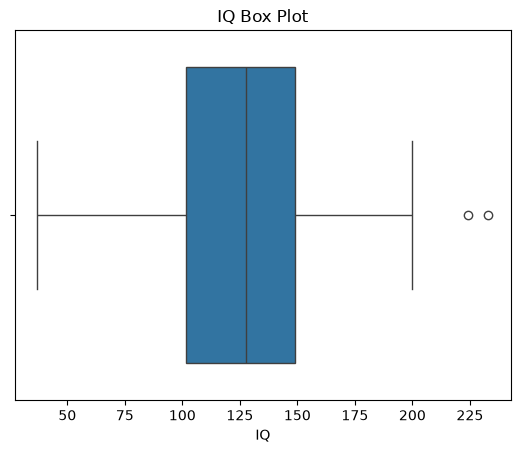

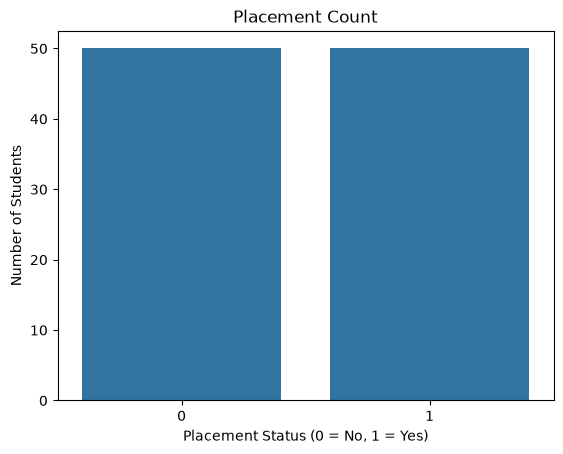

Placement counts:
placement
0    50
1    50
Name: count, dtype: int64


In [13]:
# histogram plot for "cgpa" column
sns.histplot(data=df, x="cgpa", bins=10, kde=True)
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

# box plot for "cgpa" column
sns.boxplot(x="cgpa", data=df)
plt.title("CGPA Box Plot")
plt.xlabel("CGPA")
plt.show()

# histogram plot for "iq" column
sns.histplot(data=df, x="iq", bins=10, kde=True)
plt.title("IQ Distribution")
plt.xlabel("IQ")
plt.ylabel("Count")
plt.show()

# box plot for "iq" column
sns.boxplot(x="iq", data=df)
plt.title("IQ Box Plot")
plt.xlabel("IQ")
plt.show()

# count plot for "placement" column
placement_counts = df["placement"].value_counts().sort_index()
sns.countplot(data=df, x="placement")
plt.title("Placement Count")
plt.xlabel("Placement Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()

print("Placement counts:")
print(placement_counts)

Next we study relationships between variables. The chapter first compares `cgpa`
and `iq`, then adds `placement` as the class label. This helps us see whether a
simple boundary may separate placed and not placed students.

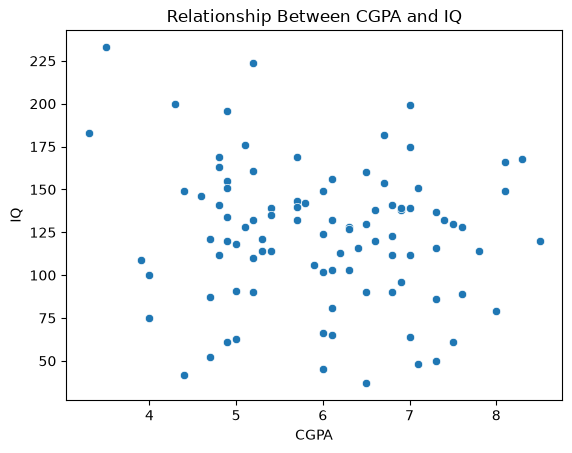

Correlation between CGPA and IQ:
          cgpa        iq
cgpa  1.000000 -0.128172
iq   -0.128172  1.000000


In [14]:
# scatter plot to showcase relationship between "cgpa" and "iq" column
sns.scatterplot(data=df, x="cgpa", y="iq")
plt.title("Relationship Between CGPA and IQ")
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

correlation = df[["cgpa", "iq"]].corr()
print("Correlation between CGPA and IQ:")
print(correlation)

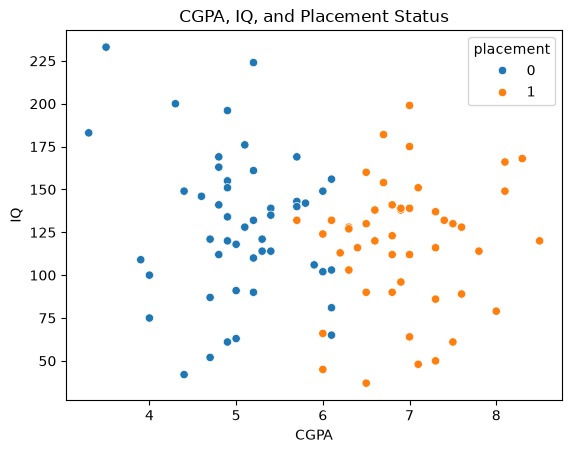

In [15]:
# scatter plot to showcase relationship between "cgpa" and "iq" column , with hue of "placement" column
sns.scatterplot(data=df, x="cgpa", y="iq", hue="placement")
plt.title("CGPA, IQ, and Placement Status")
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

The scatter plot shows that placed students generally have higher CGPA values.
The two classes also look close to linearly separable, which makes Logistic
Regression a reasonable first model for this chapter.

## Step 5 - Feature Engineering

Feature engineering means preparing the input columns in the form required by the
model.

Firstly, we will fill missing `cgpa` values using mean imputation

In [40]:
print("Missing values before CGPA mean imputation:")
print(df.isna().sum())

mean_cgpa = df["cgpa"].mean()
df["cgpa"] = df["cgpa"].fillna(mean_cgpa)

print("\nMissing values after CGPA mean imputation:")
print(df.isna().sum())

Missing values before CGPA mean imputation:
cgpa         5
iq           0
placement    0
dtype: int64

Missing values after CGPA mean imputation:
cgpa         0
iq           0
placement    0
dtype: int64


Now we will cap unusually high `iq` values at 200


In [41]:
print("Rows with IQ greater than 200 before capping:")
print(df[df["iq"] > 200])

df["iq"] = np.where(df["iq"] > 200, 200, df["iq"])

print("\nRows with IQ greater than 200 after capping:")
print(df[df["iq"] > 200])

Rows with IQ greater than 200 before capping:
    cgpa     iq  placement
16   5.2  224.0          0
50   3.5  233.0          0

Rows with IQ greater than 200 after capping:
Empty DataFrame
Columns: [cgpa, iq, placement]
Index: []


At last, we will standardize `cgpa` and `iq` so both features are on a comparable scale

In [42]:
print("Preview before standardizing CGPA and IQ:")
print(df.head())

scaler = StandardScaler()
df[["cgpa", "iq"]] = scaler.fit_transform(df[["cgpa", "iq"]])

print("\nPreview after standardizing CGPA and IQ:")
print(df.head())

Preview before standardizing CGPA and IQ:
   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0

Preview after standardizing CGPA and IQ:
       cgpa        iq  placement
0  0.723422 -0.000260          1
1 -0.078816 -0.442829          0
2 -0.613642 -0.052327          0
3  1.258247  0.234041          1
4 -0.167954  0.494375          0


After standardization, both input features are centered around 0 and scaled by
their variation. This prevents one feature from dominating only because its raw
numeric range is larger.

## Step 6 - Model Building

Now we separate the input features from the target column. 

`X` contains the
student measurements, and `y` contains the placement label that the model must
learn to predict.

In [44]:
# features column
X = df[["cgpa", "iq"]]

# target column
y = df["placement"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (100, 2)
Target vector shape: (100,)


We split the data into training and testing sets. The model learns from the
training set, and we reserve the test set for evaluation on unseen data.

In [45]:
# split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 80
Testing rows: 20


Logistic Regression is used here because the output is binary: placed or not
placed. The model learns a decision boundary that separates the two classes as
well as possible.

In [46]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model training complete.")
print("Learned coefficients:", model.coef_)
print("Learned intercept:", model.intercept_)

Model training complete.
Learned coefficients: [[3.09414369 0.26684409]]
Learned intercept: [-0.02031036]


## Step 7 - Model Evaluation

A trained model is useful only if it performs well on data - it did not see during
training. We predict the test-set labels and compare them with the true labels.

In [47]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": y_pred,
})

print("Actual vs predicted values for the test set:")
print(results.head(10))

Actual vs predicted values for the test set:
   actual  predicted
0       1          1
1       1          1
2       1          1
3       1          1
4       0          0
5       0          0
6       0          1
7       1          1
8       0          0
9       0          0


In [50]:
# calculating accuracy of our ML model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 85.00%


The accuracy tells us what percentage of test examples were classified correctly by our trained ML model.

## Plotting the Decision Boundary

The final plot visualizes the decision boundary learned by Logistic Regression.

It helps us visualize how the model distinguishes between students who are placed and those who are not, based on their CGPA and IQ scores.

We will use `mlxtend.plotting.plot_decision_regions` for this
visualization.

C:\Users\RUPINDER SINGH\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


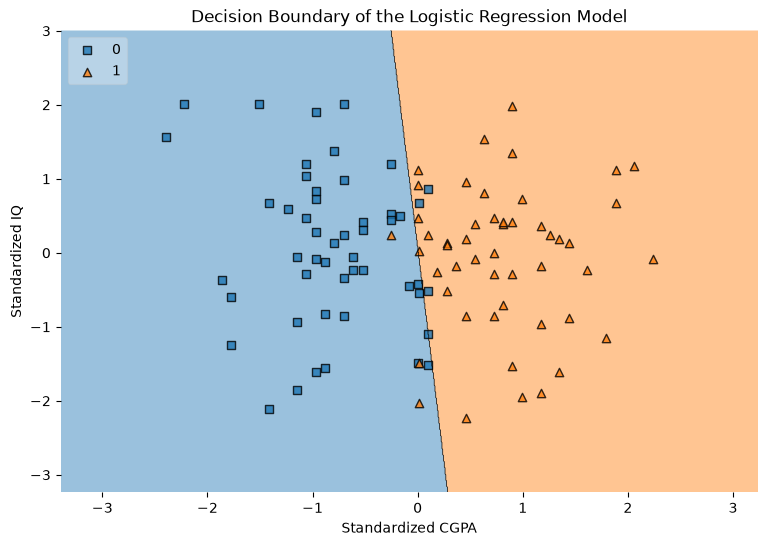

In [51]:
# combine training and test data for plotting
X_combined = pd.concat([X_train, X_test])
y_combined = pd.concat([y_train, y_test])

# plot the decision boundary
plt.figure(figsize=(9, 6))
plot_decision_regions(X_combined.values, y_combined.values, clf=model, legend=2)

# adding axis labels and title
plt.title("Decision Boundary of the Logistic Regression Model")
plt.xlabel("Standardized CGPA")
plt.ylabel("Standardized IQ")
plt.show()

## Chapter Recap

In this chapter we completed one end-to-end Machine Learning workflow.

- We loaded the placement dataset.
- We converted text columns into numeric columns.
- We explored feature distributions and relationships.
- We handled missing values and outliers.
- We standardized the input features.
- We trained a Logistic Regression model.
- We evaluated the model using accuracy and a confusion matrix.
- We visualized the learned decision boundary.

While our model performs well, there's always room for improvement! In chapters to follow, we will zoom in on each step we have touched upon while building this project.

